# **Análisis Exploratorio de Datos**

# 1. Librerías

In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np

# 2. Datos

In [127]:
# Cargar los datos desde el archivo CSV
df = pd.read_csv('/content/datos_utf.csv', encoding="latin1")

<ipython-input-127-98c23bcd2b7e>:2: DtypeWarning: Columns (27,43,100,113,116,137,198,244,250,253,257,259,270,272,368,434,457,458,459,475,476,477,480,481,482,485,507,522) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/datos_utf.csv', encoding="latin1")


## 2.1. Tamaño de los Datos

In [128]:
# Imprimir numero de filas y numero de columnas

print("Número de filas de la GEIH 2024:", df.shape[0])
print("Número de columnas de la GEIH 2024:", df.shape[1])

Número de filas de la GEIH 2024: 834560
Número de columnas de la GEIH 2024: 525


## 2.2. Selección de Variables

In [129]:
variables_migracion = [
    "P6074", "P755", "P755S1", "P755S2", "P755S3", "P754", "P753", "P753S1",
    "P753S2", "P753S3", "P752", "P1662", "P3271", "P3373S1", "P3373S2",
    "P3373S3", "P3374", "P3375", "P3376", "P3377", "P3378S1", "P3379",
    "P3380", "P3381", "P3382", "P3382S1", "P3382S2", "P3382S3", "P3383",
    "P3384", "P3384S1", "P3384S2", "P3384S3", "P3385", "P3386"
]

variables_datos_vivienda = [
    "P4000", "P4030S1", "P4030S2", "P4030S3", "P4030S4", "P4030S5", "P70"
]

variables_datos_hogar = [
    "P5010", "P5020", "P5040", "P5050", "P5070", "P5080", "P5090",
    "P5222S1", "P5222S2", "P5222S3", "P5222S4", "P5222S5", "P5222S6",
    "P5222S7", "P5222S8", "P5222S9", "P5222S10", "P6008"
]

variables_car_grales = [
    "P3271", "P3271", "P6040", "P6050", "P2057", "P2061", "P6080", "P6070", "P6071"
]

variables_ssocial = [
    "P6090", "P6100", "P6110"
]

variables_educacion = [
    "P6160", "P6170", "P3042", "P3043"
]

variables_mlaboral = [
    "P6240", "P6240S1", "P6240S2", "P6250", "P6260", "P6270", "P6280", "P6290",
    "P6300", "P6320", "P6330", "P6340", "P6350", "P6351", "P6360", "P6440",
    "P6450", "P6460", "P6422", "P6424S1", "P6424S2", "P6424S3", "P6424S5",
    "P6426", "P6430", "P6480", "P6500", "P6510", "P6510S1", "P6765", "P3051",
    "P3064", "P6780", "P1879", "P1805", "P6800", "P6810", "P6915", "P6920",
    "P6930", "P6940", "P6960", "P6990", "P9450", "P1880", "P7040", "P7070",
    "P7090", "P7100", "P7130", "P7140S1", "P7140S2", "P7140S3", "P7140S4",
    "P7140S5", "P7140S6", "P7140S7", "P7140S8", "P7140S9", "P7170S1",
    "P7170S5", "P7170S6", "P514", "P515", "P1882", "P7250", "P7270", "P744",
    "P3074", "P7450", "P7350", "P9460", "P1519", "P7505", "P7510S1",
    "P7510S2", "P7510S3", "P750S1", "P750S2", "P1661S1", "P1661S2",
    "P1661S3", "P1661S4", "P750S3"
]

# Combinar todas las listas en una sola lista final de columnas
variables_seleccionadas = (
    variables_migracion +
    variables_datos_vivienda +
    variables_datos_hogar +
    variables_car_grales +
    variables_ssocial +
    variables_educacion +
    variables_mlaboral
)

In [130]:
# Crear nuevo dataset solo con las columnas seleccionadas (si existen)
geih_2024_filtrada = df[[col for col in variables_seleccionadas if col in df.columns]]

In [131]:
# Guardar como CSV
geih_2024_filtrada.to_csv("geih_2024_filtrado.csv", index=False)

## 2.3. Seleccionar unicamente a los Jefes de Hogar como Unidad de Estudio

In [132]:
# 1. Filtrar las filas
filas_cumplen = geih_2024_filtrada[
    (geih_2024_filtrada['P6050'] == 1) &
    (geih_2024_filtrada['P3382'].notna())
]

# 2. Contar las filas
num_filas_cumplen = len(filas_cumplen)
print("Número de filas que cumplen con la condición (P6050 = 1 y P3382 no es NA):", num_filas_cumplen)

# 3. Guardar en archivos nuevos
filas_cumplen.to_csv("geih_2024_jefe_de_hogar.csv", index=False)

Número de filas que cumplen con la condición (P6050 = 1 y P3382 no es NA): 291714


In [133]:
# Cargar los datos desde el archivo CSV
df_jefe_hogar = pd.read_csv('/content/geih_2024_jefe_de_hogar.csv', encoding="latin1")

# Imprimir información básica del DataFrame
print("Información del DataFrame:")
print(df_jefe_hogar.info())

# Mostrar las primeras filas del DataFrame
print("\nPrimeras filas del DataFrame:")
print(df_jefe_hogar.head())


<ipython-input-133-11e3a7526a71>:2: DtypeWarning: Columns (1,2,3,13,14,15,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df_jefe_hogar = pd.read_csv('/content/geih_2024_jefe_de_hogar.csv', encoding="latin1")


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291714 entries, 0 to 291713
Columns: 145 entries, P3271 to P750S3
dtypes: float64(109), int64(26), object(10)
memory usage: 322.7+ MB
None

Primeras filas del DataFrame:
   P3271 P3373S1  P3373S2 P3373S3  P3374  P3375  P3376  P3377  P3378S1  \
0      1    44.0  44430.0     NaN      1    NaN    2.0    NaN      NaN   
1      1     NaN      NaN     NaN      1    NaN    1.0    1.0    204.0   
2      1    47.0  47268.0     NaN      1    NaN    2.0    NaN      NaN   
3      2     NaN      NaN     NaN      1    NaN    2.0    NaN      NaN   
4      1     NaN      NaN     NaN      1    NaN    2.0    NaN      NaN   

    P3379  ...  P7510S1  P7510S2  P7510S3 P750S1 P750S2 P1661S1  P1661S2  \
0     NaN  ...      NaN      NaN      NaN    NaN    NaN     NaN      NaN   
1  1999.0  ...      NaN      NaN      NaN    NaN    NaN     NaN      NaN   
2     NaN  ...      NaN      NaN      NaN    NaN    NaN     NaN      NaN   
3   

In [134]:
# identificando que tipo de variables son las columnas de geih_2024_filtrado

# Identificar el tipo de variables en geih_2024_filtrado
tipos_variables = df_jefe_hogar.dtypes

# Imprimir los tipos de variables
print(tipos_variables)

# Puedes iterar sobre las columnas y sus tipos para una visualización más detallada
for columna, tipo in tipos_variables.items():
  print(f"La columna '{columna}' es de tipo: {tipo}")


P3271        int64
P3373S1     object
P3373S2     object
P3373S3     object
P3374        int64
            ...   
P1661S1    float64
P1661S2    float64
P1661S3    float64
P1661S4    float64
P750S3     float64
Length: 145, dtype: object
La columna 'P3271' es de tipo: int64
La columna 'P3373S1' es de tipo: object
La columna 'P3373S2' es de tipo: object
La columna 'P3373S3' es de tipo: object
La columna 'P3374' es de tipo: int64
La columna 'P3375' es de tipo: float64
La columna 'P3376' es de tipo: float64
La columna 'P3377' es de tipo: float64
La columna 'P3378S1' es de tipo: float64
La columna 'P3379' es de tipo: float64
La columna 'P3380' es de tipo: float64
La columna 'P3381' es de tipo: float64
La columna 'P3382' es de tipo: int64
La columna 'P3382S1' es de tipo: object
La columna 'P3382S2' es de tipo: object
La columna 'P3382S3' es de tipo: object
La columna 'P3383' es de tipo: float64
La columna 'P3384' es de tipo: int64
La columna 'P3384S1' es de tipo: object
La columna 'P3384S2' e

In [135]:
# Iterar sobre las columnas del DataFrame y convertirlas a enteros usando Int64
for columna in df_jefe_hogar.columns:
  try:
    df_jefe_hogar[columna] = pd.to_numeric(df_jefe_hogar[columna], errors='coerce').astype('Int64')
  except:
    # Si no se puede convertir a entero, omitir la columna (opcional)
    pass

# Imprimir el DataFrame con las columnas convertidas a entero
print(df_jefe_hogar.head())

# Imprimir los tipos de datos de las columnas
df_jefe_hogar.dtypes

   P3271  P3373S1  P3373S2  P3373S3  P3374  P3375  P3376  P3377  P3378S1  \
0      1       44    44430     <NA>      1   <NA>      2   <NA>     <NA>   
1      1     <NA>     <NA>     <NA>      1   <NA>      1      1      204   
2      1       47    47268     <NA>      1   <NA>      2   <NA>     <NA>   
3      2     <NA>     <NA>     <NA>      1   <NA>      2   <NA>     <NA>   
4      1     <NA>     <NA>     <NA>      1   <NA>      2   <NA>     <NA>   

   P3379  ...  P7510S1  P7510S2  P7510S3  P750S1  P750S2  P1661S1  P1661S2  \
0   <NA>  ...     <NA>     <NA>     <NA>    <NA>    <NA>     <NA>     <NA>   
1   1999  ...     <NA>     <NA>     <NA>    <NA>    <NA>     <NA>     <NA>   
2   <NA>  ...     <NA>     <NA>     <NA>    <NA>    <NA>     <NA>     <NA>   
3   <NA>  ...     <NA>     <NA>     <NA>    <NA>    <NA>     <NA>     <NA>   
4   <NA>  ...     <NA>     <NA>     <NA>    <NA>    <NA>     <NA>     <NA>   

   P1661S3  P1661S4  P750S3  
0     <NA>     <NA>    <NA>  
1     <NA>    

,0
P3271,Int64
P3373S1,Int64
P3373S2,Int64
P3373S3,Int64
P3374,Int64
...,...
P1661S1,Int64
P1661S2,Int64
P1661S3,Int64
P1661S4,Int64


In [136]:
# Iterar sobre las columnas del DataFrame y mostrar los valores únicos
for columna in df_jefe_hogar.columns:
  print(f"Valores únicos de la columna '{columna}':")
  print(df_jefe_hogar[columna].unique())
  print("-" * 50)


Valores únicos de la columna 'P3271':
<IntegerArray>
[1, 2]
Length: 2, dtype: Int64
--------------------------------------------------
Valores únicos de la columna 'P3373S1':
<IntegerArray>
[  44, <NA>,   47,   68,   54,   76,    5,   17,   70,   23,   11,   73,   27,
   50,    8,   25,   52,   13,   15,   41,   85,   66,   63,   19,   18,   86,
   81,   94,   95,   20,   99,   97,   91,   88]
Length: 34, dtype: Int64
--------------------------------------------------
Valores únicos de la columna 'P3373S2':
<IntegerArray>
[44430,  <NA>, 47268, 44078, 47030, 44035, 44560, 68001, 54128, 54001,
 ...
 97511, 13160, 94663, 15550, 25260, 91430, 13490, 91460, 15832, 25793]
Length: 1122, dtype: Int64
--------------------------------------------------
Valores únicos de la columna 'P3373S3':
<IntegerArray>
[<NA>,  862,  222,  630,  643,  214,  218,  724,   76,  616,  528,  752,  604,
   32,  152,  840,  768,  422,  250,  364,  276,  484,  340,  410,  380,  591,
  372,  558,  156,  388,  600,  53

## 2.4. Renombrar Variables

In [137]:
# Renombrar variables
df_jefe_hogar = df_jefe_hogar.rename(columns={
    'P4000': 'tipo_vivienda',
    'P4030S1': 'servicios_basicos',
    'P70': 'hogares_vivienda'
})

# Recodificar: sexo_jefe_hogar → 1: masculino, 0: femenino
df_jefe_hogar['servicios_basicos'] = df_jefe_hogar['servicios_basicos'].replace({
    1: 1,  # Si
    2: 0   # No
})


# Reemplazar valores de tipo_vivienda con las 3 categorías nuevas
df_jefe_hogar['tipo_vivienda'] = df_jefe_hogar['tipo_vivienda'].replace({
    1: 1,  # Casa
    2: 1,  # Apartamento
    3: 2,  # Cuarto (inquilinato)
    4: 2,  # Cuarto (otra estructura)
    5: 3,  # Vivienda indígena
    6: 3   # Otra vivienda (carpa, vagón, etc.)
})

In [138]:
# Renombrar columnas
df_jefe_hogar = df_jefe_hogar.rename(columns={
    'P3271': 'sexo_jefe_hogar',
    'P6040': 'edad_jefe_hogar',
    'P2057': 'campesino',
    'P2061': 'comunidad_campesina',
    'P6080': 'grupo_etnico',
    'P6070': 'estado_civil'
})

# Recodificar: sexo_jefe_hogar → 1: masculino, 0: femenino
df_jefe_hogar['sexo_jefe_hogar'] = df_jefe_hogar['sexo_jefe_hogar'].replace({
    1: 1,  # Masculino
    2: 0   # Femenino
})

# edad_jefe_hogar se deja tal cual, representa la edad en años

# Recodificar: campesino → 1 si es campesino (1), 0 si no o no informa (2, 9)
df_jefe_hogar['campesino'] = df_jefe_hogar['campesino'].replace({
    1: 1,
    2: 0,
    9: 0
})

# Recodificar: comunidad_campesina → 1 si sí (1), 0 si no o no informa (2, 9)
df_jefe_hogar['comunidad_campesina'] = df_jefe_hogar['comunidad_campesina'].replace({
    1: 1,
    2: 0,
    9: 0
})

# Recodificar: grupo_etnico → 1 si pertenece a un grupo étnico (1-5), 0 si no (6)
df_jefe_hogar['grupo_etnico'] = df_jefe_hogar['grupo_etnico'].isin([1, 2, 3, 4, 5]).astype(int)

# Recodificar: estado_civil
df_jefe_hogar['estado_civil'] = df_jefe_hogar['estado_civil'].replace({
    1: 1, 2: 1,        # Convive
    3: 2,              # Casado
    4: 3, 5: 3, 6: 3   # Separado, divorciado, viudo, soltero
})



In [139]:
# Renombrar la variable P6090 como 'eps'
df_jefe_hogar = df_jefe_hogar.rename(columns={
    'P6090': 'eps'
})

# Recodificar: 1 → 1 (sí), 2 o 9 → 0 (no o no informa)
df_jefe_hogar['eps'] = df_jefe_hogar['eps'].replace({
    1: 1,
    2: 0,
    9: 0
})

In [140]:
# Renombrar columnas
df_jefe_hogar = df_jefe_hogar.rename(columns={
    'P6160': 'alfabeto_jefe_hogar',
    'P6170': 'estudia_jefe_hogar',
    'P3042': 'nivel_educativo_jefe_hogar'
})

# Recodificar: alfabeto_jefe_hogar (1: sí, 2: no)
df_jefe_hogar['alfabeto_jefe_hogar'] = df_jefe_hogar['alfabeto_jefe_hogar'].replace({
    1: 1,
    2: 0
})

# Recodificar: estudia_jefe_hogar (1: sí, 2: no)
df_jefe_hogar['estudia_jefe_hogar'] = df_jefe_hogar['estudia_jefe_hogar'].replace({
    1: 1,
    2: 0
})

# Recodificar: nivel_educativo_jefe_hogar en 5 niveles
df_jefe_hogar['nivel_educativo_jefe_hogar'] = df_jefe_hogar['nivel_educativo_jefe_hogar'].replace({
    1: 1, 2: 1, 99: 1,           # Ninguno o no sabe
    3: 2, 4: 2,                 # Básica
    5: 3, 6: 3,                 # Media
    7: 4, 8: 4, 9: 4,           # Técnica
    10: 5, 11: 5, 12: 5, 13: 5  # Universitaria y superior
})


In [141]:
# Renombrar columnas
df_jefe_hogar = df_jefe_hogar.rename(columns={
    'P6240': 'actividad_laboral_jefe_hogar',
    'P6440': 'contrato',
    'P6422': 'conforme_tipo_contrato',
    'P6800': 'horas_trabajo',
    'P6920': 'cotiza',
    'P1880': 'razon_abandono_empleo_anterior',
    'P7090': 'deseo_trabajar_mas',
    'P7130': 'desea_cambiar_trabajo',
    'P514':  'estabilidad_laboral',
    'P1882': 'tiempo_desplazamiento'
})

# Recodificar: actividad_laboral_jefe_hogar
# 1-5 se mantienen, 6 y NA se agrupan como 6 (Otra actividad y NA)
df_jefe_hogar['actividad_laboral_jefe_hogar'] = df_jefe_hogar['actividad_laboral_jefe_hogar'].apply(
    lambda x: x if x in [1, 2, 3, 4, 5] else 6
)

# Recodificar: contrato
df_jefe_hogar['contrato'] = df_jefe_hogar['contrato'].replace({
    1: 1,
    2: 0
}).fillna(0).astype(int)

# Recodificar: conforme_tipo_contrato
df_jefe_hogar['conforme_tipo_contrato'] = df_jefe_hogar['conforme_tipo_contrato'].replace({
    1: 1,
    2: 0
}).fillna(0).astype(int)

# Reemplazar valores NA en horas_trabajo por 0 (y mantener los demás igual)
df_jefe_hogar['horas_trabajo'] = df_jefe_hogar['horas_trabajo'].fillna(0)


# Recodificar: cotiza
df_jefe_hogar['cotiza'] = df_jefe_hogar['cotiza'].replace({
    1: 1,
    2: 0,
    3: 0
}).fillna(0).astype(int)

# Reemplazar NA por 13 en razon_abandono_empleo_anterior
df_jefe_hogar['razon_abandono_empleo_anterior'] = df_jefe_hogar['razon_abandono_empleo_anterior'].fillna(13).astype(int)

# Recodificar: deseo_trabajar_mas
df_jefe_hogar['deseo_trabajar_mas'] = df_jefe_hogar['deseo_trabajar_mas'].replace({
    1: 1,
    2: 0
}).fillna(0).astype(int)

# Recodificar: desea_cambiar_trabajo
df_jefe_hogar['desea_cambiar_trabajo'] = df_jefe_hogar['desea_cambiar_trabajo'].replace({
    1: 1,
    2: 0
}).fillna(0).astype(int)

# Recodificar: estabilidad_laboral
df_jefe_hogar['estabilidad_laboral'] = df_jefe_hogar['estabilidad_laboral'].replace({
    1: 1,
    2: 0
}).fillna(0).astype(int)

# Reemplazar NA por 0 en tiempo_desplazamiento
df_jefe_hogar['tiempo_desplazamiento'] = df_jefe_hogar['tiempo_desplazamiento'].fillna(0)



In [143]:
# Renombrar columnas
df_jefe_hogar = df_jefe_hogar.rename(columns={
    'P755S1': 'departamento_residencia_5_anos',
    'P3373S1': 'departamento_nacimiento',
    'P3374': 'nacionalidad',
    'P3382S1': 'departamento_residencia_5_anos',
    'P3383': 'lugar_residencia_5_anos',
    'P3384S1': 'departamento_residencia_1_ano',
    'P3385': 'lugar_residencia_1_ano',
    'P3386': 'motivo_cambio_residencia'
})

# Recodificar: nacionalidad (1: colombiana, 0: no colombiana)
df_jefe_hogar['nacionalidad'] = df_jefe_hogar['nacionalidad'].replace({
    1: 1,
    2: 0,
    3: 0
})

# Recodificar: lugar_residencia_5_anos (1: cabecera, 2: rural)
df_jefe_hogar['lugar_residencia_5_anos'] = df_jefe_hogar['lugar_residencia_5_anos'].replace({
    1: 1,
    2: 0
})

# Recodificar: lugar_residencia_1_ano (1: cabecera, 2: rural)
df_jefe_hogar['lugar_residencia_1_ano'] = df_jefe_hogar['lugar_residencia_1_ano'].replace({
    1: 1,
    2: 0
})

# Reemplazar NaN por categoría extra "NA" (por ejemplo: 99) en todas estas variables
variables_con_na_final = [
    'departamento_residencia_5_anos',
    'departamento_nacimiento',
    'lugar_residencia_5_anos',
    'departamento_residencia_1_ano',
    'lugar_residencia_1_ano',
    'motivo_cambio_residencia'
]

# Asignar categoría especial 99 a los NA
for var in variables_con_na_final:
    df_jefe_hogar[var] = df_jefe_hogar[var].fillna(99).astype(int)



## 2.5. Seleccionar Variables para Análisis Exploratorio

In [144]:
# Lista de variables deseadas
variables_finales = [
    'tipo_vivienda',
    'servicios_basicos',
    'hogares_vivienda',
    'sexo_jefe_hogar',
    'edad_jefe_hogar',
    'campesino',
    'comunidad_campesina',
    'grupo_etnico',
    'estado_civil',
    'eps',
    'alfabeto_jefe_hogar',
    'estudia_jefe_hogar',
    'nivel_educativo_jefe_hogar',
    'actividad_laboral_jefe_hogar',
    'contrato',
    'conforme_tipo_contrato',
    'horas_trabajo',
    'cotiza',
    'razon_abandono_empleo_anterior',
    'deseo_trabajar_mas',
    'desea_cambiar_trabajo',
    'estabilidad_laboral',
    'tiempo_desplazamiento',
    'departamento_residencia_5_anos',
    'departamento_nacimiento',
    'nacionalidad',
    'lugar_residencia_5_anos',
    'departamento_residencia_1_ano',
    'lugar_residencia_1_ano',
    'motivo_cambio_residencia'
]

# Crear nuevo DataFrame con esas columnas
geih_2024_final = df_jefe_hogar[variables_finales].copy()

# Verificar las dimensiones del nuevo dataset
print("Dimensiones del nuevo DataFrame:", geih_2024_final.shape)

# Vista previa
geih_2024_final.head()


Dimensiones del nuevo DataFrame: (291714, 30)


,tipo_vivienda,servicios_basicos,hogares_vivienda,sexo_jefe_hogar,edad_jefe_hogar,campesino,comunidad_campesina,grupo_etnico,estado_civil,eps,...,desea_cambiar_trabajo,estabilidad_laboral,tiempo_desplazamiento,departamento_residencia_5_anos,departamento_nacimiento,nacionalidad,lugar_residencia_5_anos,departamento_residencia_1_ano,lugar_residencia_1_ano,motivo_cambio_residencia
0,1,1,1,1,43,1,1,1,3,0,...,0,1,3,99,44,1,0,99,0,99
1,1,1,1,1,44,1,1,1,1,1,...,0,1,5,99,99,1,0,99,0,99
2,1,1,1,1,67,1,1,0,1,1,...,0,1,5,47,47,1,1,99,0,99
3,2,1,1,0,24,1,1,1,3,1,...,0,1,2,99,99,1,0,99,0,99
4,2,1,1,1,21,1,1,1,1,1,...,0,1,4,99,99,1,0,99,0,99


# 3. Análisis Exploratorio de Datos

## 3.1. Verificar que no existan valores nulos en la base de datos

In [145]:
# Contar la cantidad de valores NA en cada columna del DataFrame geih_2024_final
na_counts = geih_2024_final.isna().sum()

# Imprimir los conteos de NA para cada columna
print("Conteo de valores NA en cada columna:")
print(na_counts)

# Calcular la cantidad total de valores NA en el DataFrame
total_na_count = geih_2024_final.isna().sum().sum()

# Imprimir el conteo total de NA
print("\nConteo total de valores NA en el DataFrame:", total_na_count)


Conteo de valores NA en cada columna:
tipo_vivienda                     0
servicios_basicos                 0
hogares_vivienda                  0
sexo_jefe_hogar                   0
edad_jefe_hogar                   0
campesino                         0
comunidad_campesina               0
grupo_etnico                      0
estado_civil                      0
eps                               0
alfabeto_jefe_hogar               0
estudia_jefe_hogar                0
nivel_educativo_jefe_hogar        0
actividad_laboral_jefe_hogar      0
contrato                          0
conforme_tipo_contrato            0
horas_trabajo                     0
cotiza                            0
razon_abandono_empleo_anterior    0
deseo_trabajar_mas                0
desea_cambiar_trabajo             0
estabilidad_laboral               0
tiempo_desplazamiento             0
departamento_residencia_5_anos    0
departamento_nacimiento           0
nacionalidad                      0
lugar_residencia_5_anos   

In [146]:
# Iterar sobre las columnas del DataFrame y mostrar los valores únicos
for columna in geih_2024_final.columns:
  print(f"Valores únicos de la columna '{columna}':")
  print(geih_2024_final[columna].unique())
  print("-" * 50)

Valores únicos de la columna 'tipo_vivienda':
<IntegerArray>
[1, 2, 3]
Length: 3, dtype: Int64
--------------------------------------------------
Valores únicos de la columna 'servicios_basicos':
<IntegerArray>
[1, 0]
Length: 2, dtype: Int64
--------------------------------------------------
Valores únicos de la columna 'hogares_vivienda':
<IntegerArray>
[1, 2, 3, 6, 5, 9, 4, 7]
Length: 8, dtype: Int64
--------------------------------------------------
Valores únicos de la columna 'sexo_jefe_hogar':
<IntegerArray>
[1, 0]
Length: 2, dtype: Int64
--------------------------------------------------
Valores únicos de la columna 'edad_jefe_hogar':
<IntegerArray>
[ 43,  44,  67,  24,  21,  31,  59,  23,  28,  35,  19,  34,  53,  37,  75,
  46,  52,  33,  38,  42,  58,  32,  41,  68,  66,  76,  56,  36,  54,  30,
  50,  64,  61,  65,  29,  57,  71,  70,  69,  48,  81,  88,  63,  55,  45,
  39,  85,  83,  78, 103,  51,  49,  72,  25,  62,  27,  79,  26,  40,  18,
  60,  47,  73,  80,  77,  74, 

In [147]:
# === Detectar tipos de variables ===
binarias = [col for col in geih_2024_final.columns if geih_2024_final[col].nunique() == 2]
continuas = ['horas_trabajo', 'tiempo_desplazamiento']
categ_multiples = [col for col in geih_2024_final.columns if col not in binarias + continuas]

## 3.2. Histogramas para variables continuas

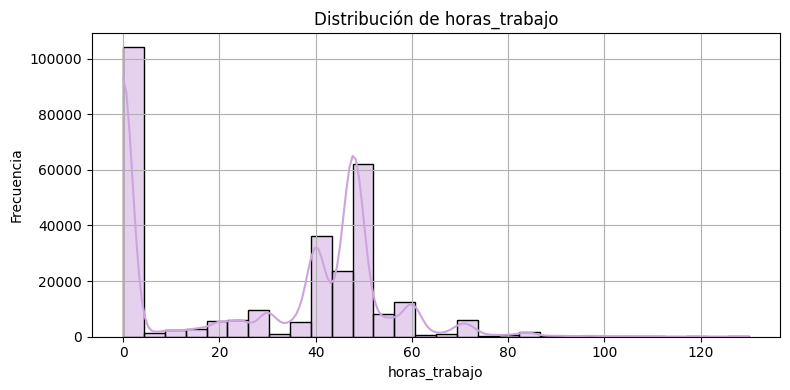

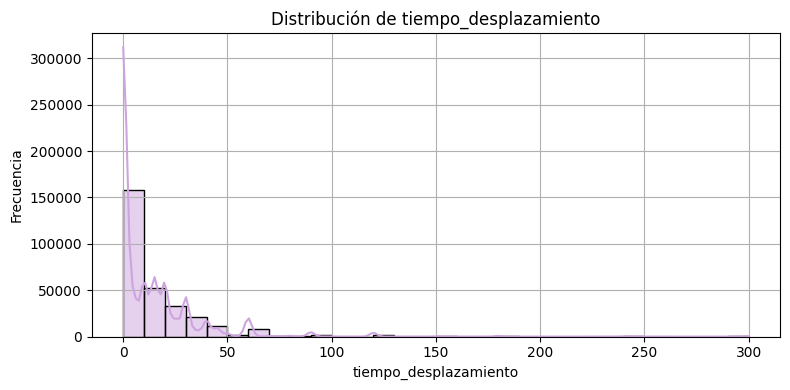

In [93]:
# Histogramas con color verde pastel
for col in continuas:
    plt.figure(figsize=(8, 4))
    sns.histplot(
        geih_2024_final[col],
        kde=True,
        bins=30,
        color='#cda4de'
    )
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## 3.3. Barras para variables binarias (dummies)

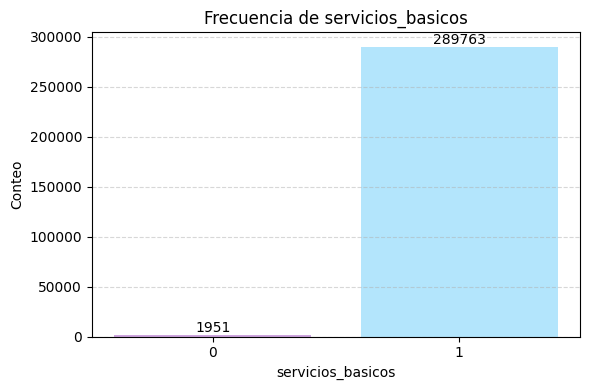

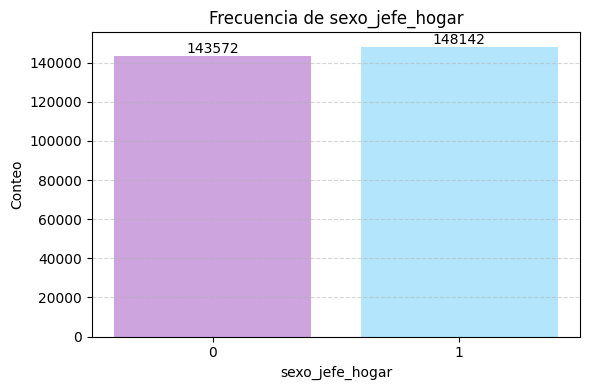

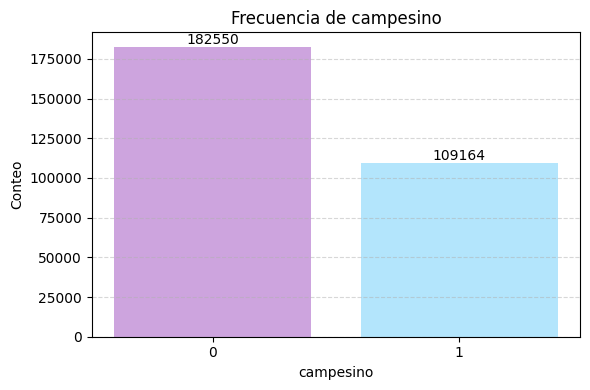

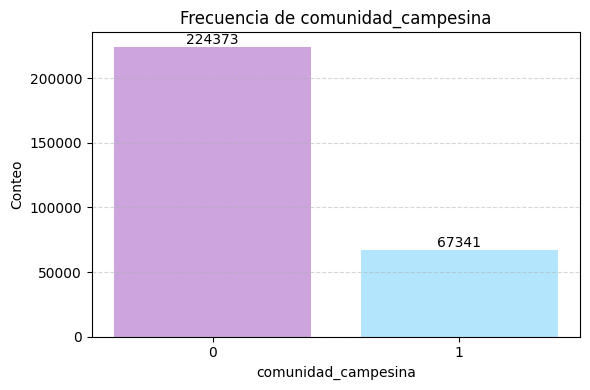

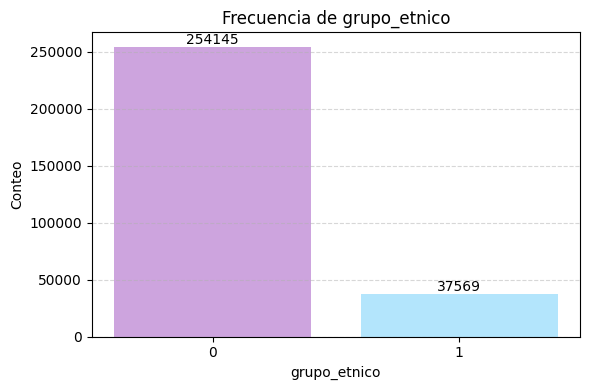

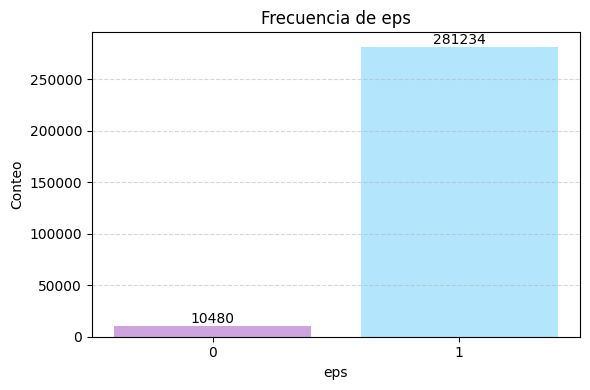

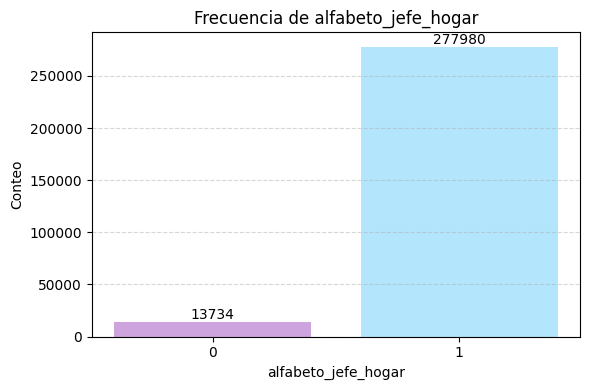

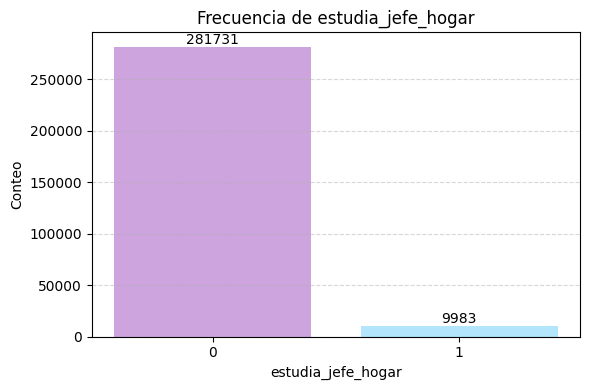

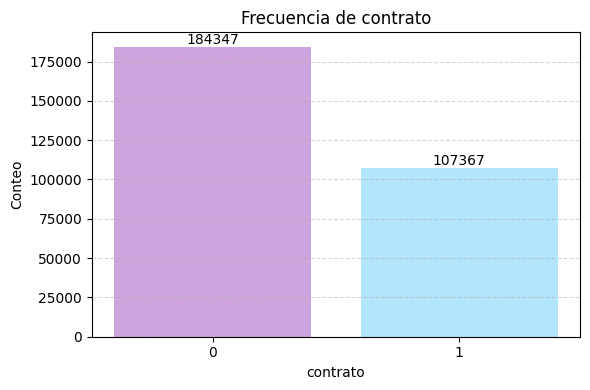

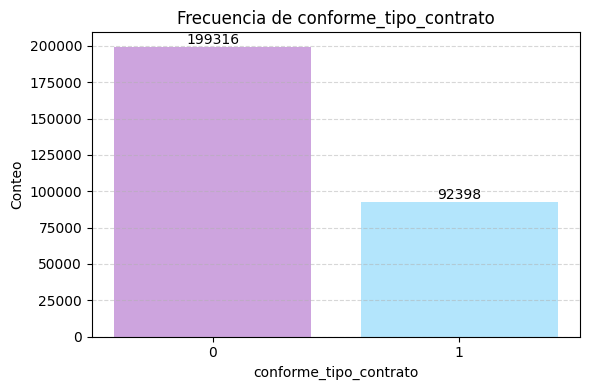

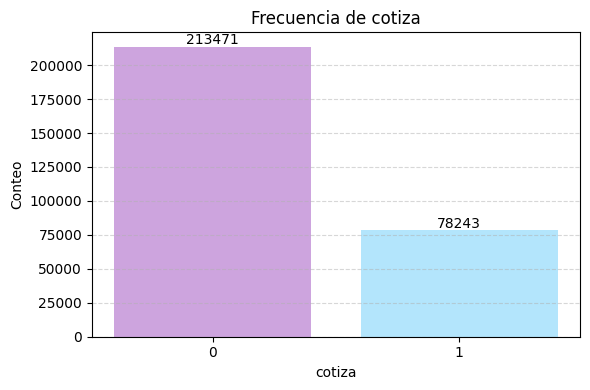

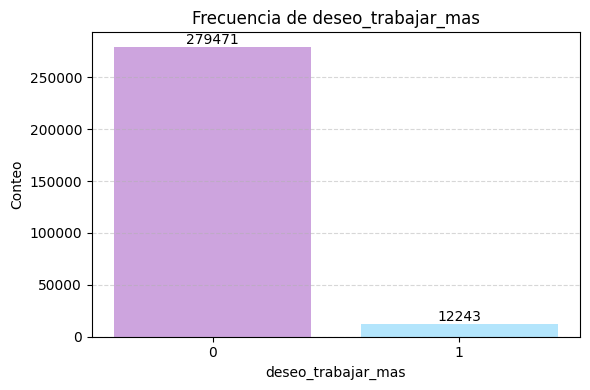

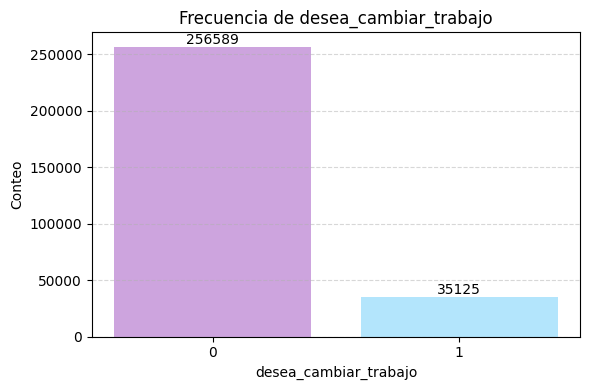

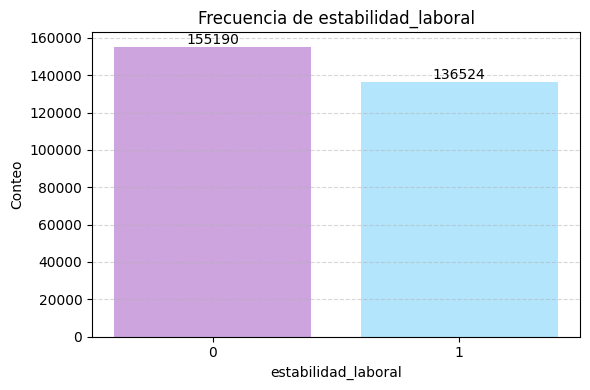

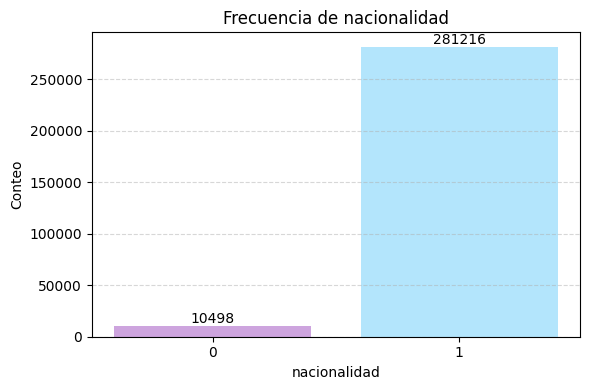

In [148]:
# === Barras para variables binarias (dummies) ===
import matplotlib.pyplot as plt

# Colores: violeta pastel y amarillo pastel
colores = {0: '#cda4de', 1: '#b3e5fc'}

for col in binarias:
    plt.figure(figsize=(6, 4))

    # Conteo de valores
    valores = geih_2024_final[col].value_counts().sort_index()

    # Barras con color personalizado
    plt.bar(
        valores.index.astype(str),
        valores.values,
        color=[colores.get(i, '#cccccc') for i in valores.index]
    )

    # Títulos y etiquetas
    plt.title(f'Frecuencia de {col}')
    plt.xlabel(col)
    plt.ylabel('Conteo')
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)

    # Mostrar valor arriba de cada barra
    for i, val in enumerate(valores):
        plt.text(i, val + max(valores)*0.01, str(val), ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()


## 3.4. Barras para variables categóricas con múltiples valores

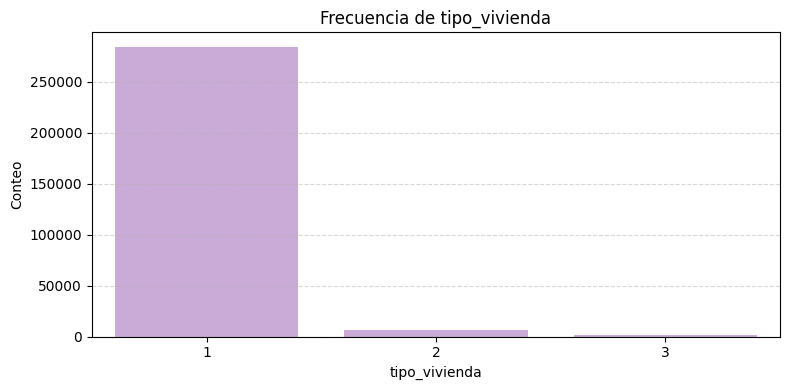

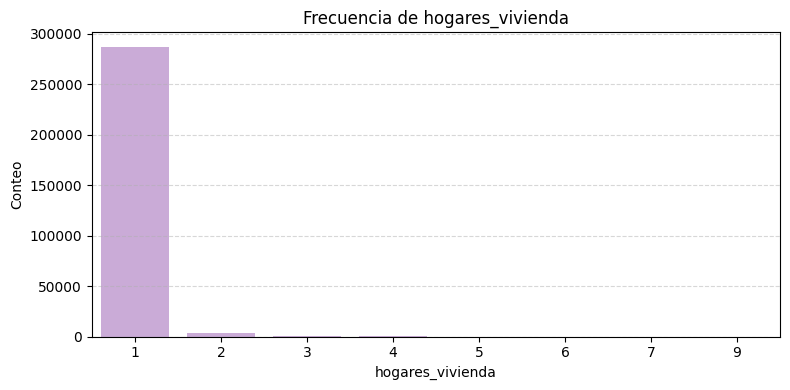

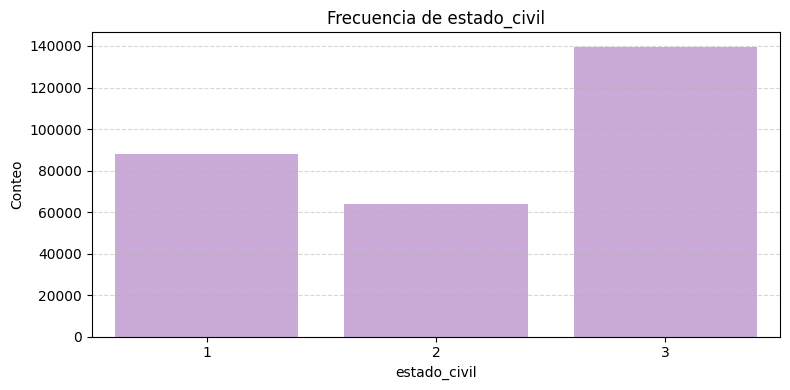

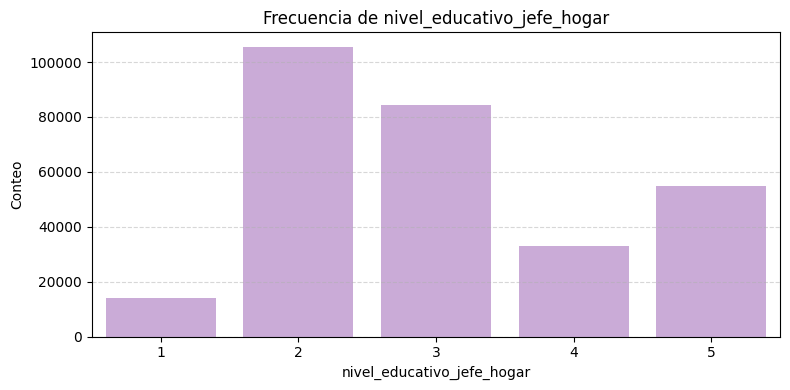

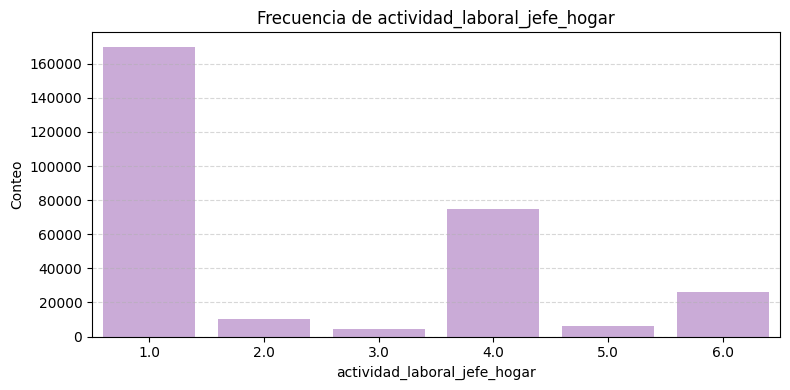

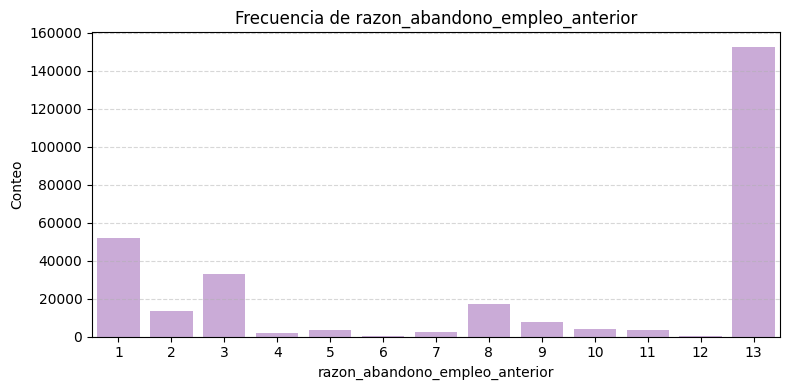

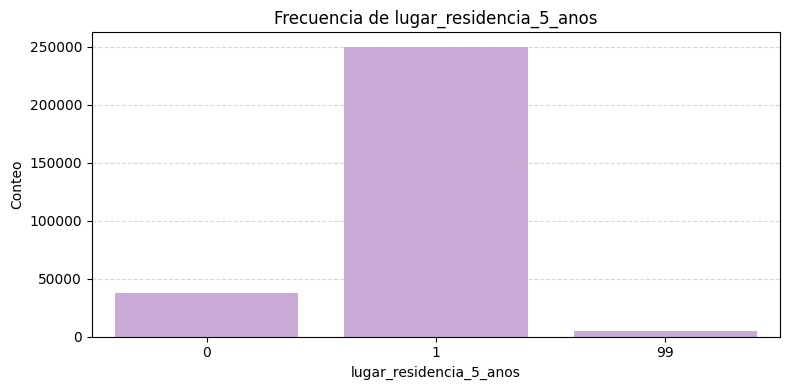

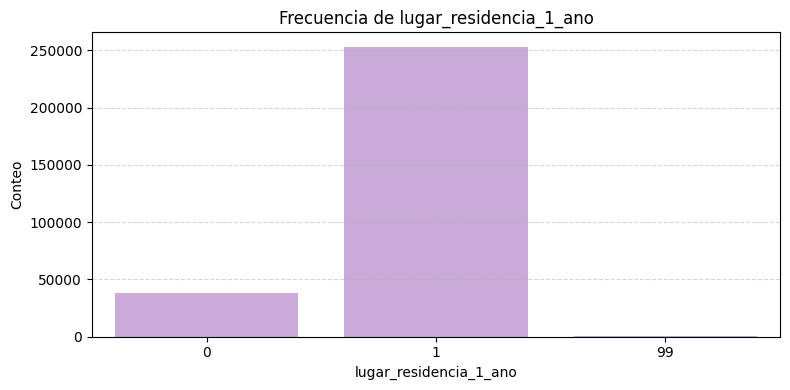

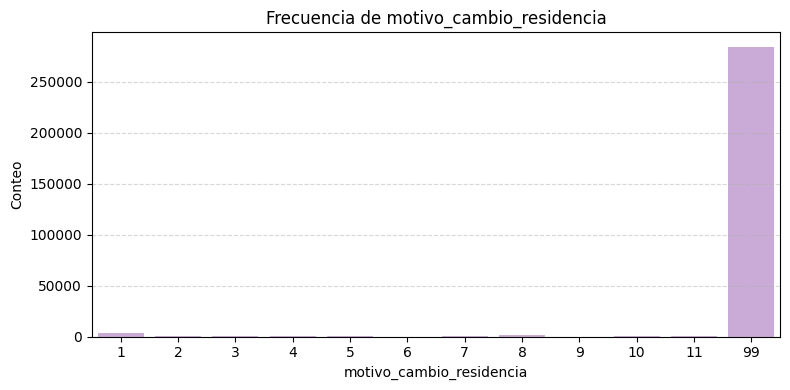

In [149]:
# === Barras para variables categóricas con múltiples valores ===
for col in categ_multiples:
    if geih_2024_final[col].nunique() < 30:  # Evitar gráficos muy cargados
        plt.figure(figsize=(8, 4))
        sns.countplot(
            x=col,
            data=geih_2024_final,
            order=sorted(geih_2024_final[col].dropna().unique()),
            color='#cda4de'  # Violeta pastel
        )
        plt.title(f'Frecuencia de {col}')
        plt.xlabel(col)
        plt.ylabel('Conteo')
        plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()



3.5. Matriz de correlación para binarias y continuas

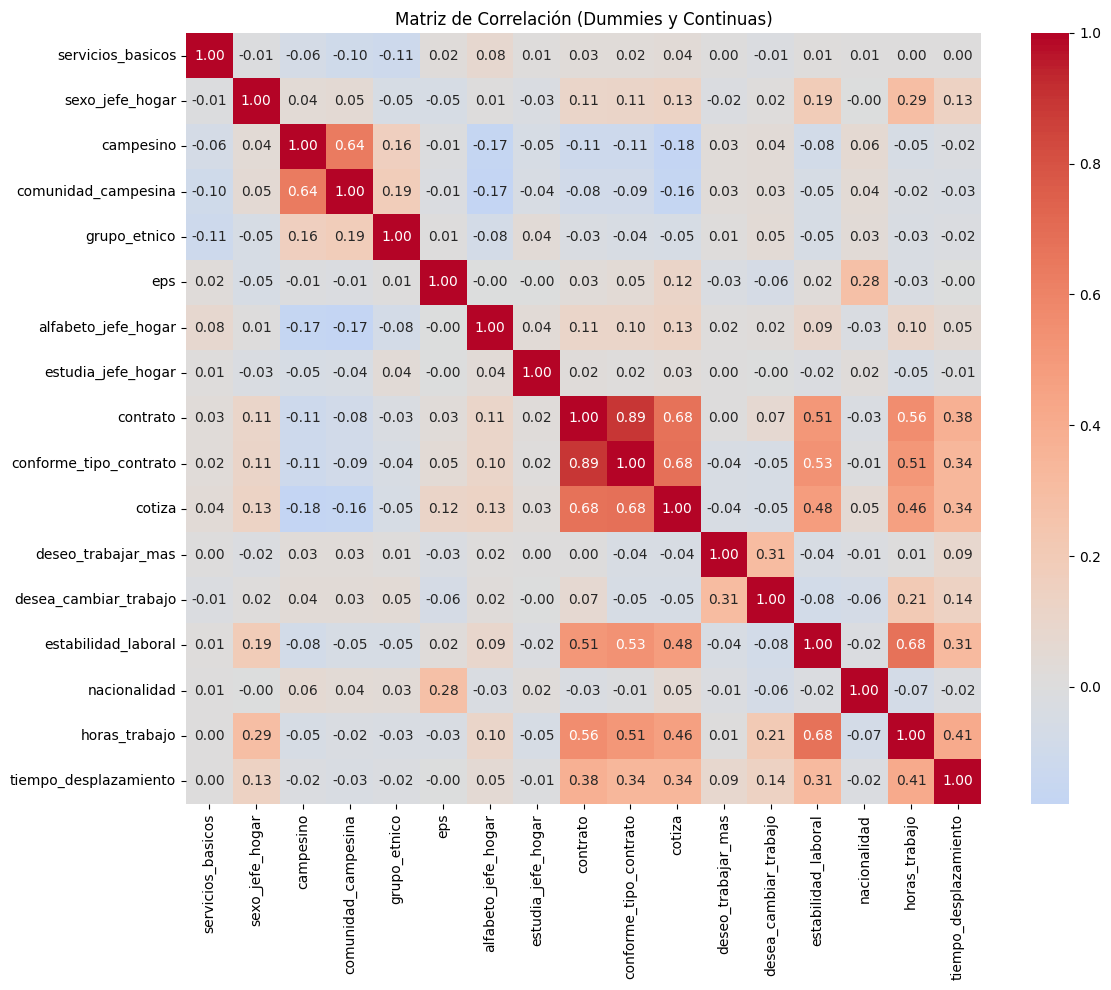

In [150]:
# === Matriz de correlación para binarias y continuas ===
plt.figure(figsize=(12, 10))
corr = geih_2024_final[binarias + continuas].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Matriz de Correlación (Dummies y Continuas)')
plt.tight_layout()
plt.show()

## 3.6. Resumen estadístico

In [151]:
# === Resumen estadístico ===
resumen = geih_2024_final.describe(include='all')
print("Resumen estadístico general:")
display(resumen)

Resumen estadístico general:


,tipo_vivienda,servicios_basicos,hogares_vivienda,sexo_jefe_hogar,edad_jefe_hogar,campesino,comunidad_campesina,grupo_etnico,estado_civil,eps,...,desea_cambiar_trabajo,estabilidad_laboral,tiempo_desplazamiento,departamento_residencia_5_anos,departamento_nacimiento,nacionalidad,lugar_residencia_5_anos,departamento_residencia_1_ano,lugar_residencia_1_ano,motivo_cambio_residencia
count,291714.0,291714.0,291714.0,291714.0,291714.0,291714.0,291714.0,291714.000000,291714.0,291714.0,...,291714.000000,291714.000000,291714.0,291714.000000,291714.000000,291714.0,291714.000000,291714.000000,291714.000000,291714.000000
mean,1.031737,0.993312,1.020729,0.507833,50.050947,0.374216,0.230846,0.128787,2.176745,0.964074,...,0.120409,0.468006,13.18163,93.585971,68.636569,0.964013,2.357254,97.721964,1.123433,96.577072
std,0.204472,0.081507,0.19017,0.499939,16.644364,0.483921,0.421375,0.334965,0.865525,0.186105,...,0.325440,0.498976,21.522523,19.373450,35.376129,0.186259,11.995995,9.655665,4.993837,15.009321
min,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.000000,1.0,0.0,...,0.000000,0.000000,0.0,5.000000,5.000000,0.0,0.000000,5.000000,0.000000,1.000000
25%,1.0,1.0,1.0,0.0,37.0,0.0,0.0,0.000000,1.0,1.0,...,0.000000,0.000000,0.0,99.000000,27.000000,1.0,1.000000,99.000000,1.000000,99.000000
50%,1.0,1.0,1.0,1.0,49.0,0.0,0.0,0.000000,2.0,1.0,...,0.000000,0.000000,5.0,99.000000,99.000000,1.0,1.000000,99.000000,1.000000,99.000000
75%,1.0,1.0,1.0,1.0,62.0,1.0,0.0,0.000000,3.0,1.0,...,0.000000,1.000000,20.0,99.000000,99.000000,1.0,1.000000,99.000000,1.000000,99.000000
max,3.0,1.0,9.0,1.0,108.0,1.0,1.0,1.000000,3.0,1.0,...,1.000000,1.000000,300.0,99.000000,99.000000,1.0,99.000000,99.000000,99.000000,99.000000
